# Machine Learning Model Comparison

This notebook provides an initial comparison of machine-learning algorithms for building classification and evaluates their performance on the prepared training, validation, and test data.

**Input**
- Preprocessed machine-learning training, validation, and test datasets.

**Output**
- Performance comparison of candidate machine-learning models.


In [ ]:
# =====================================================================
# CELL 1 — Imports & Config
# =====================================================================
import numpy as np
import joblib
import os
import json
import warnings
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Which hierarchical level to train — change this one line to switch levels
# Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'flat_l1'

print(f"Training level: {LEVEL}")

Training level: flat_l1


In [2]:
# =====================================================================
# CELL 2 — Load Data for This Level
# =====================================================================
X_train, y_train = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_train_scaled.pkl'))
X_val,   y_val   = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_val_scaled.pkl'))
X_test,  y_test  = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_test_scaled.pkl'))
classes          = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_classes.pkl'))
feature_cols     = joblib.load(os.path.join(ML_DIR, 'feature_cols.pkl'))

# Convert DataFrames to numpy if needed (they may be DataFrames from your pkl)
if hasattr(X_train, 'values'):
    X_train = X_train.values
    X_val   = X_val.values
    X_test  = X_test.values

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {classes}")

n_classes = len(np.unique(y_train))

X_train : (7772053, 110)
X_val   : (457180, 110)
X_test  : (914360, 110)
Classes : ['agricultural' 'civic' 'commercial' 'industrial' 'military' 'residential'
 'transportation']


In [3]:
# =====================================================================
# CELL 3 — Evaluation Helper (used by every model)
# =====================================================================
def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        y_pred = model.predict(X_sp)
        # Handle XGBoost which returns float
        if hasattr(y_pred, 'astype'):
            y_pred = y_pred.astype(int)

        report = classification_report(y_sp, y_pred,
                                       target_names=classes,
                                       output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')

        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
        }
        print(f"\n{model_name} — {split_name.upper()}")
        print(f"  Macro F1    : {macro_f1:.4f}")
        print(f"  Weighted F1 : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    # Confusion matrix on test
    y_pred_test = model.predict(X_test).astype(int)
    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=120)
    plt.show()

    return results


all_results = {}  # accumulates results from all models for comparison

In [ ]:

N_JOBS = -1

# Balanced weights for XGBoost
xgb_train_weights = compute_sample_weight('balanced', y_train).astype(np.float32)
xgb_val_weights = compute_sample_weight('balanced', y_val).astype(np.float32)

MODEL_CONFIGS = {

    'decision_tree': {
        'cls': DecisionTreeClassifier,
        'params': {
            'criterion': 'gini',
            'max_depth': 30,
            'min_samples_split': 20,
            'min_samples_leaf': 10,
            'class_weight': 'balanced',
            'random_state': 42,
        },
        'fit_kwargs': {},
    },

    'random_forest': {
        'cls': RandomForestClassifier,
        'params': {
            'n_estimators': 500,
            'max_depth': None,
            'min_samples_split': 4,
            'min_samples_leaf': 2,
            'max_features': 'sqrt',
            'bootstrap': True,
            'class_weight': 'balanced_subsample',
            'n_jobs': N_JOBS,
            'random_state': 42,
        },
        'fit_kwargs': {},
    },

    'xgboost': {
            'cls': xgb.XGBClassifier,
            'params': {
                'n_estimators'     : 5000,
                'max_depth'        : 7,
                'learning_rate'    : 0.05,
                'subsample'        : 0.8,
                'colsample_bytree' : 0.8,
                'use_label_encoder': False,
                'eval_metric'      : 'mlogloss',
                'early_stopping_rounds': 50,
                'n_jobs'           : N_JOBS,
                'random_state'     : 42,
                'tree_method'      : 'hist',    # fast on large data
            },
            # eval_set used for early stopping — val set only
            'fit_kwargs': {'eval_set': [(X_val, y_val)], 'verbose': 100},
        },
    
    'lightgbm': {
        'cls': lgb.LGBMClassifier,
        'params': {
            'n_estimators'      : 5000,
            'max_depth'         : -1,
            'num_leaves'        : 127,     # ↑ — more expressive
            'learning_rate'     : 0.03,
            'subsample'         : 0.8,
            'subsample_freq'    : 1,
            'colsample_bytree'  : 0.7,
            'min_child_samples' : 20,      # prevents overfitting on tiny classes
            'reg_alpha'         : 0.1,
            'reg_lambda'        : 1.0,
            # DO NOT use class_weight='balanced' — it caused the precision collapse
            # Use is_unbalance instead — gentler correction
            'is_unbalance'      : True,    # ← replaces class_weight='balanced'
            'n_jobs'            : N_JOBS,
            'random_state'      : 42,
            'verbosity'         : -1,
        },
        'fit_kwargs': {
            'eval_set'  : [(X_val, y_val)],
            'callbacks' : [lgb.early_stopping(100), lgb.log_evaluation(200)],
        },
    },

    'catboost': {
        'cls': cb.CatBoostClassifier,
        'params': {
            'iterations': 3000,
            'depth': 8,
            'learning_rate': 0.05,
            'l2_leaf_reg': 3.0,
            'random_strength': 1.0,
            'loss_function': 'MultiClass',
            'eval_metric': 'TotalF1:average=Macro',
            'auto_class_weights': 'Balanced',
            'early_stopping_rounds': 100,
            'random_seed': 42,
            'verbose': 100,
            'allow_writing_files': False,
        },
        'fit_kwargs': {
            'eval_set': (X_val, y_val),
        },
    },

    'logistic_regression': {
        'cls': LogisticRegression,
        'params': {
            'C': 1.0,
            'solver': 'saga',
            'class_weight': 'balanced',
            'max_iter': 1000,
            'tol': 1e-3,
            'random_state': 42,
        },
        'fit_kwargs': {},
    },

    'linear_svm': {
        'cls': LinearSVC,
        'params': {
            'C': 1.0,
            'class_weight': 'balanced',
            'dual': 'auto',
            'tol': 1e-3,
            'max_iter': 5000,
            'random_state': 42,
        },
        'fit_kwargs': {},
    },
}


Training DECISION_TREE — level: flat_l1
Finished training decision_tree. Evaluating...

decision_tree — VAL
  Macro F1    : 0.4713
  Weighted F1 : 0.8275
                precision    recall  f1-score   support

  agricultural     0.3734    0.7950    0.5081     15681
         civic     0.2666    0.6089    0.3709     15575
    commercial     0.2901    0.5024    0.3678     21046
    industrial     0.4539    0.6454    0.5330     15086
      military     0.2623    0.7319    0.3862       414
   residential     0.9839    0.8246    0.8973    388263
transportation     0.1531    0.5166    0.2362      1115

      accuracy                         0.7947    457180
     macro avg     0.3976    0.6607    0.4713    457180
  weighted avg     0.8864    0.7947    0.8275    457180


decision_tree — TEST
  Macro F1    : 0.4699
  Weighted F1 : 0.8282
                precision    recall  f1-score   support

  agricultural     0.3723    0.7910    0.5063     31361
         civic     0.2692    0.6093    0.3734

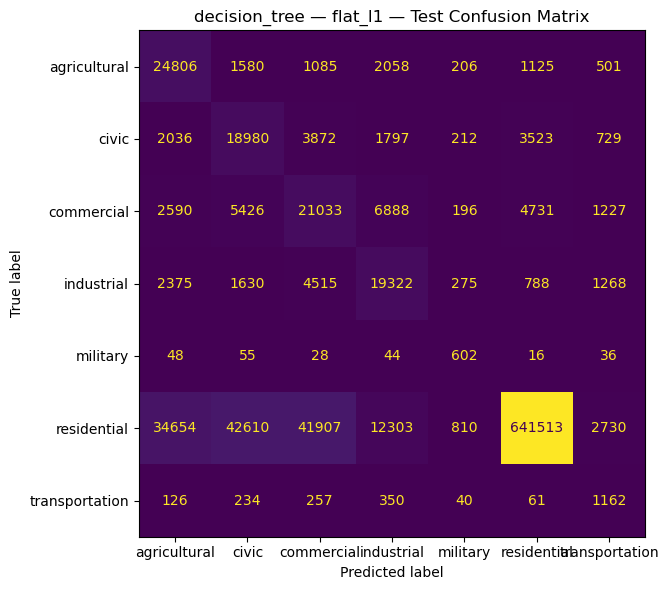

Saving model decision_tree...
Saved → /fast/home/o-olajuyigbe/osm_project/data/models/flat_l1_decision_tree.pkl

Training RANDOM_FOREST — level: flat_l1
Finished training random_forest. Evaluating...

random_forest — VAL
  Macro F1    : 0.7005
  Weighted F1 : 0.9209
                precision    recall  f1-score   support

  agricultural     0.7427    0.7267    0.7346     15681
         civic     0.7415    0.5077    0.6027     15575
    commercial     0.7049    0.4963    0.5825     21046
    industrial     0.7471    0.7108    0.7285     15086
      military     0.9364    0.7464    0.8306       414
   residential     0.9529    0.9845    0.9685    388263
transportation     0.6994    0.3381    0.4559      1115

      accuracy                         0.9261    457180
     macro avg     0.7893    0.6444    0.7005    457180
  weighted avg     0.9197    0.9261    0.9209    457180


random_forest — TEST
  Macro F1    : 0.6987
  Weighted F1 : 0.9202
                precision    recall  f1-score 

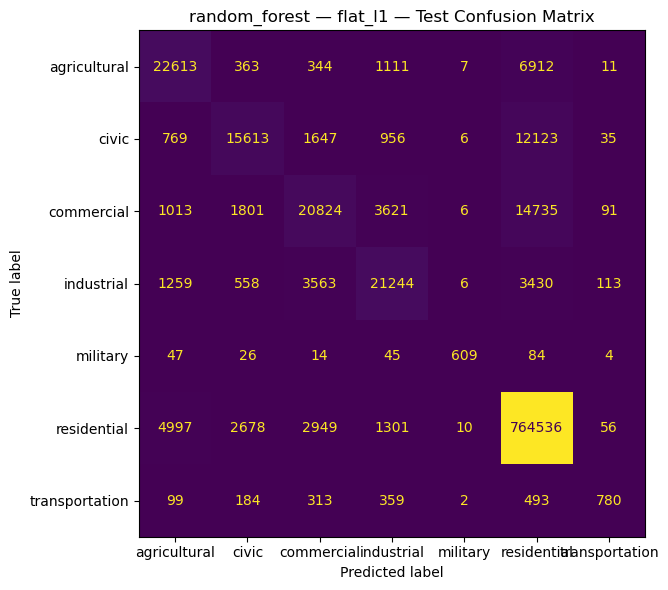

Saving model random_forest...
Saved → /fast/home/o-olajuyigbe/osm_project/data/models/flat_l1_random_forest.pkl

Training XGBOOST — level: flat_l1
[0]	validation_0-mlogloss:0.59103
[100]	validation_0-mlogloss:0.26726
[200]	validation_0-mlogloss:0.25273
[300]	validation_0-mlogloss:0.24653
[400]	validation_0-mlogloss:0.24257
[500]	validation_0-mlogloss:0.23956
[600]	validation_0-mlogloss:0.23700
[700]	validation_0-mlogloss:0.23477
[800]	validation_0-mlogloss:0.23280
[900]	validation_0-mlogloss:0.23112
[1000]	validation_0-mlogloss:0.22959
[1100]	validation_0-mlogloss:0.22819
[1200]	validation_0-mlogloss:0.22692
[1300]	validation_0-mlogloss:0.22571
[1400]	validation_0-mlogloss:0.22459
[1500]	validation_0-mlogloss:0.22353
[1600]	validation_0-mlogloss:0.22254
[1700]	validation_0-mlogloss:0.22162
[1800]	validation_0-mlogloss:0.22075
[1900]	validation_0-mlogloss:0.21985
[2000]	validation_0-mlogloss:0.21903
[2100]	validation_0-mlogloss:0.21827
[2200]	validation_0-mlogloss:0.21752
[2300]	validat

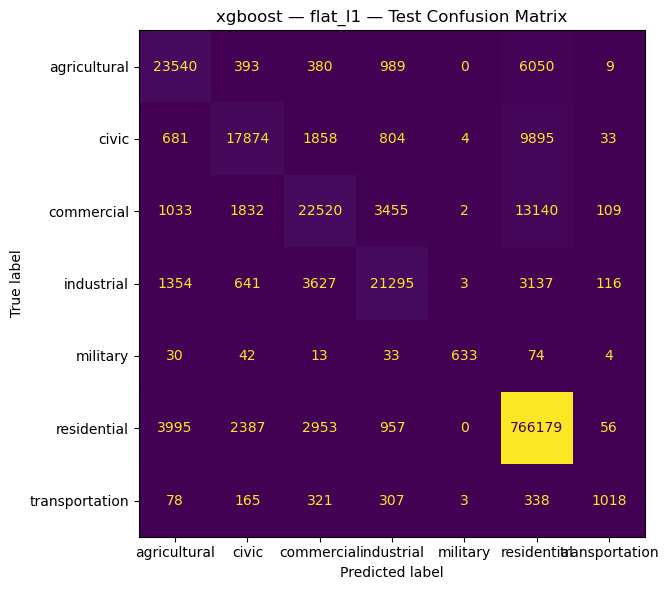

Saving model xgboost...
Saved → /fast/home/o-olajuyigbe/osm_project/data/models/flat_l1_xgboost.pkl

Training LIGHTGBM — level: flat_l1
Training until validation scores don't improve for 100 rounds
[200]	valid_0's multi_logloss: 0.24079
[400]	valid_0's multi_logloss: 0.230471
[600]	valid_0's multi_logloss: 0.225865
[800]	valid_0's multi_logloss: 0.222548
[1000]	valid_0's multi_logloss: 0.220058
[1200]	valid_0's multi_logloss: 0.21788
[1400]	valid_0's multi_logloss: 0.215975
[1600]	valid_0's multi_logloss: 0.214286
[1800]	valid_0's multi_logloss: 0.212758
[2000]	valid_0's multi_logloss: 0.211367
[2200]	valid_0's multi_logloss: 0.210098
[2400]	valid_0's multi_logloss: 0.208886
[2600]	valid_0's multi_logloss: 0.207799
[2800]	valid_0's multi_logloss: 0.206782
[3000]	valid_0's multi_logloss: 0.205854
[3200]	valid_0's multi_logloss: 0.204994
[3400]	valid_0's multi_logloss: 0.204176
[3600]	valid_0's multi_logloss: 0.203447
[3800]	valid_0's multi_logloss: 0.202764
[4000]	valid_0's multi_loglos

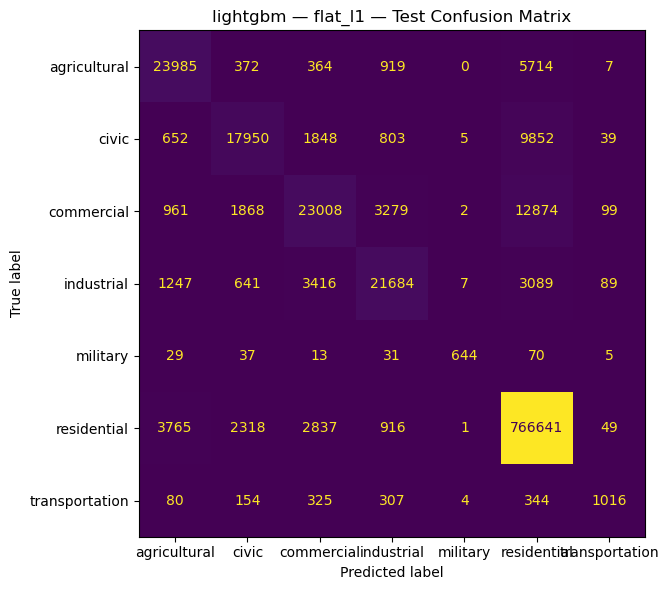

Saving model lightgbm...
Saved → /fast/home/o-olajuyigbe/osm_project/data/models/flat_l1_lightgbm.pkl

Training CATBOOST — level: flat_l1
0:	learn: 0.5398417	test: 0.5383957	best: 0.5383957 (0)	total: 6.06s	remaining: 5h 3m 6s
100:	learn: 0.6815360	test: 0.6814678	best: 0.6814678 (100)	total: 10m 11s	remaining: 4h 52m 41s
200:	learn: 0.7071561	test: 0.7026685	best: 0.7026685 (200)	total: 19m 50s	remaining: 4h 36m 18s
300:	learn: 0.7226641	test: 0.7153383	best: 0.7153383 (300)	total: 29m 21s	remaining: 4h 23m 15s
400:	learn: 0.7366708	test: 0.7276551	best: 0.7277227 (397)	total: 38m 39s	remaining: 4h 10m 34s
500:	learn: 0.7476009	test: 0.7353721	best: 0.7357650 (497)	total: 48m	remaining: 3h 59m 26s
600:	learn: 0.7555980	test: 0.7414902	best: 0.7414902 (600)	total: 57m 20s	remaining: 3h 48m 54s
700:	learn: 0.7628092	test: 0.7462554	best: 0.7462676 (699)	total: 1h 6m 37s	remaining: 3h 38m 31s
800:	learn: 0.7686209	test: 0.7481529	best: 0.7485815 (797)	total: 1h 15m 54s	remaining: 3h 28m 

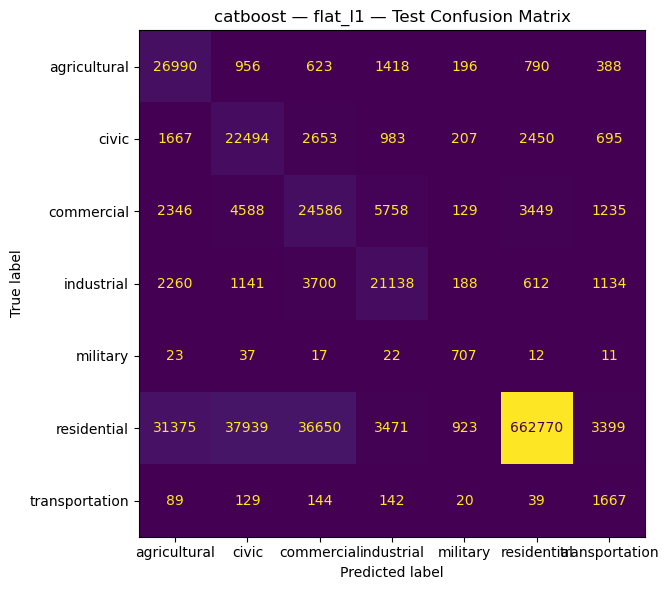

Saving model catboost...
Saved → /fast/home/o-olajuyigbe/osm_project/data/models/flat_l1_catboost.pkl

Training LOGISTIC_REGRESSION — level: flat_l1
Finished training logistic_regression. Evaluating...

logistic_regression — VAL
  Macro F1    : 0.2979
  Weighted F1 : 0.7335
                precision    recall  f1-score   support

  agricultural     0.2159    0.7132    0.3315     15681
         civic     0.2731    0.4923    0.3513     15575
    commercial     0.2276    0.3660    0.2807     21046
    industrial     0.3502    0.1953    0.2508     15086
      military     0.0128    0.8043    0.0252       414
   residential     0.9810    0.6913    0.8111    388263
transportation     0.0178    0.5650    0.0345      1115

      accuracy                         0.6537    457180
     macro avg     0.2969    0.5468    0.2979    457180
  weighted avg     0.8719    0.6537    0.7335    457180


logistic_regression — TEST
  Macro F1    : 0.2977
  Weighted F1 : 0.7346
                precision    rec

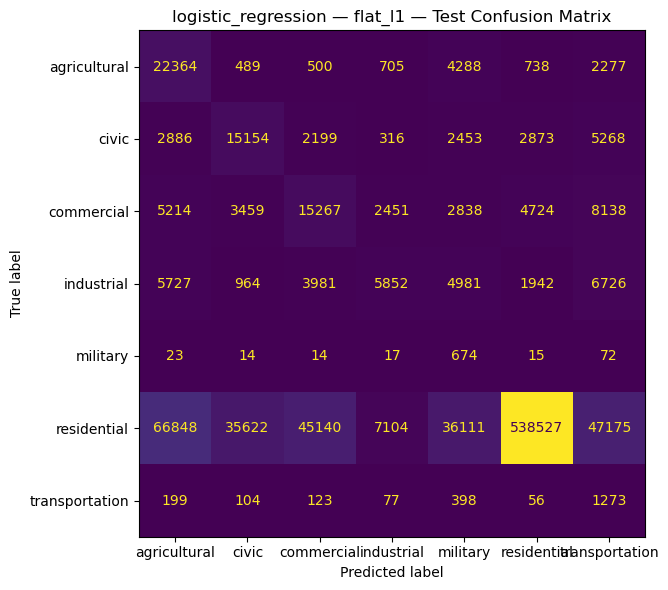

Saving model logistic_regression...
Saved → /fast/home/o-olajuyigbe/osm_project/data/models/flat_l1_logistic_regression.pkl

Training LINEAR_SVM — level: flat_l1
Finished training linear_svm. Evaluating...

linear_svm — VAL
  Macro F1    : 0.4087
  Weighted F1 : 0.8504
                precision    recall  f1-score   support

  agricultural     0.3857    0.7203    0.5024     15681
         civic     0.4489    0.4564    0.4526     15575
    commercial     0.3981    0.2909    0.3362     21046
    industrial     0.3701    0.4167    0.3921     15086
      military     0.0821    0.6836    0.1465       414
   residential     0.9548    0.9046    0.9290    388263
transportation     0.0577    0.4341    0.1018      1115

      accuracy                         0.8373    457180
     macro avg     0.3853    0.5581    0.4087    457180
  weighted avg     0.8701    0.8373    0.8504    457180


linear_svm — TEST
  Macro F1    : 0.4068
  Weighted F1 : 0.8504
                precision    recall  f1-score 

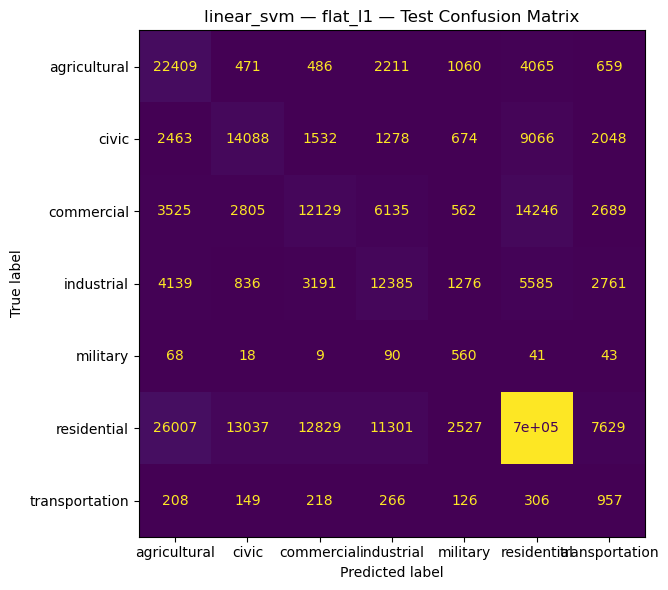

Saving model linear_svm...
Saved → /fast/home/o-olajuyigbe/osm_project/data/models/flat_l1_linear_svm.pkl


In [5]:
# =====================================================================
# CELL 5 — Train All Models
# Change MODEL_CONFIGS keys to run a subset
# =====================================================================
trained_models = {}

for model_name, cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name.upper()} — level: {LEVEL}")
    print(f"{'='*60}")

    model = cfg['cls'](**cfg['params'])
    model.fit(X_train, y_train, **cfg['fit_kwargs'])

    print(f"Finished training {model_name}. Evaluating...")

    # Evaluate
    results = evaluate(model, X_val, y_val, X_test, y_test,
                       classes, model_name, LEVEL)
    all_results[model_name] = results
    trained_models[model_name] = model

    # Save model
    print(f"Saving model {model_name}...")
    save_path = os.path.join(MODEL_DIR, f'{LEVEL}_{model_name}.pkl')
    joblib.dump(model, save_path)
    print(f"Saved → {save_path}")

In [6]:
# =====================================================================
# CELL 7 — Compare All Models on This Level
# =====================================================================
print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

# Save results to JSON for later aggregation
results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results.json')
# Make results JSON-serialisable
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — flat_l1 — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
decision_tree            0.4699        0.8282
random_forest            0.6987        0.9202
xgboost                  0.7372        0.9290
lightgbm                 0.7446        0.9311
catboost                 0.5431        0.8567
logistic_regression      0.2977        0.7346
linear_svm               0.4068        0.8504

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/flat_l1_results.json
